In [23]:
import numpy as np

A = np.array([[3,-.1,-.2],[.1,7,-.3],[.3,-.2,10]])
b = np.array([7.85,-19.3,71.4])

x_true = np.linalg.solve(A, b)

def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
            
        err = np.linalg.norm(x_new - x, ord=np.inf)
        error.append(err)

        if err < tol:
            return x_new, error
        x = x_new
    return x, error

def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    error = []
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
            
        err = np.linalg.norm(x_new - x, ord=np.inf)
        error.append(err)
        
        if err < tol:
            return x_new, error
        x = x_new
    return x, error

tol = [1e-3, 1e-6, 1e-9]
x0 = np.zeros_like(b)

for t in tol:
    sol_g, err_g = gauss_seidel(A, b, x0, t, 1000)
    sol_j, err_j = jacobi(A, b, x0, t, 1000)

    print(f"Tolerance: {t}")
    print(f"  Gauss-Seidel iterations: {len(err_g)}")
    print(f"  Jacobi iterations:       {len(err_j)}")


Tolerance: 0.001
  Gauss-Seidel iterations: 4
  Jacobi iterations:       4
Tolerance: 1e-06
  Gauss-Seidel iterations: 5
  Jacobi iterations:       7
Tolerance: 1e-09
  Gauss-Seidel iterations: 7
  Jacobi iterations:       9


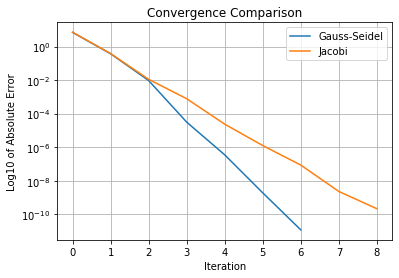

In [24]:
import matplotlib.pyplot as plt

plt.semilogy(err_g, label="Gauss-Seidel")
plt.semilogy(err_j, label="Jacobi")
plt.xlabel("Iteration")
plt.ylabel("Log10 of Absolute Error")
plt.title("Convergence Comparison")
plt.legend()
plt.grid()
plt.show()

In [22]:
#Lowering the tolerance increases the number of iterations need to reach convergence.
#This is because as tolerance gets lower the error needs to get smaller, requiring additional iterations.